# Exploratory Data Analysis (EDA) - [Titanic - Machine Learning from Disaster]

**Objective**: Predict passenger survival on the Titanic using machine learning through cleaning, and feature analysis, and model training

**Data Source**: [Kaggle: Titanic - Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

## Packages installation and libraries importation

In [245]:
pip install pandas numpy matplotlib torch scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [246]:
# Some common libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Data

In [247]:
df = pd.read_csv('data/train.csv')
print(f"Initial dataset shape: {df.shape}")
print(df.shape)
df.head()

Initial dataset shape: (891, 12)
(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data overview

In [248]:
print("Data info:")
df.info()
df.describe()
print("\nMissing values per column:")
print(df.isna().sum())
print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          

- Pclass: A proxy for socio-economic status (SES)
    + 1st = Upper
    + 2nd = Middle
    + 3rd = Lower

- Age: Age is fractional if less than 1, it in the form of x.5 if estimated

- Sibsp: The dataset defines family relations
    + Sibling = brother, sister, stepbrother, stepsister
    + Spouse = husband, wife (mistresses and fiancés were ignored)

- Parch: The dataset defines family relations in this way...
    + Parent = mother, father
    + Child = daughter, son, stepdaughter, stepson
    + Some children travelled only with a nanny, therefore parch=0 for them.

Most of the values in Cabin are missing, and PassengerId is irrelevant for analysis

In [249]:
df = df.drop(['PassengerId', 'Cabin'], axis=1)

## Data transformation and encoding

In [250]:
# Change the keys to better readable ones
df ['Embarked'] = df['Embarked'].replace(['C','S','Q'], ['Cherbourg','Southampton','Queenstown'])
df ['Survived'] = df['Survived'].replace([0, 1], ['No', 'Yes'])
df ['Pclass'] = df['Pclass'].replace([1, 2, 3], ['Upper', 'Middle', 'Lower'])

In [251]:
categorical_df = df.loc[:, df.nunique() <= 10]
print("Categorical features: ", categorical_df.columns.values)

numerical_df = df.loc[:, df.nunique() > 10]
numerical_df = numerical_df.select_dtypes(include='number')
print("Numerical features: ", numerical_df.columns.values)

Categorical features:  ['Survived' 'Pclass' 'Sex' 'SibSp' 'Parch' 'Embarked']
Numerical features:  ['Age' 'Fare']


## Univariate Analysis

Mean: 29.69911764705882 
Median: 28.0


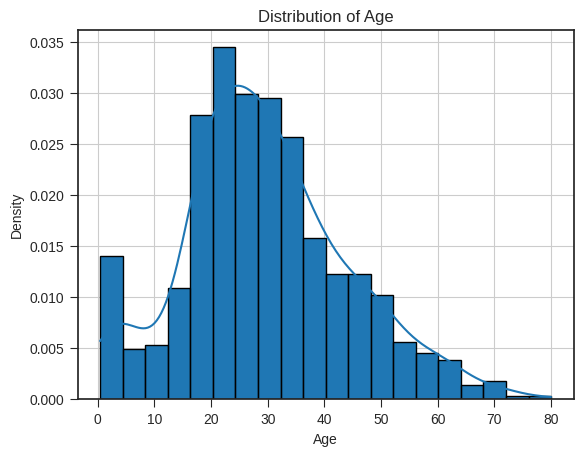

Mean: 32.204207968574636 
Median: 14.4542


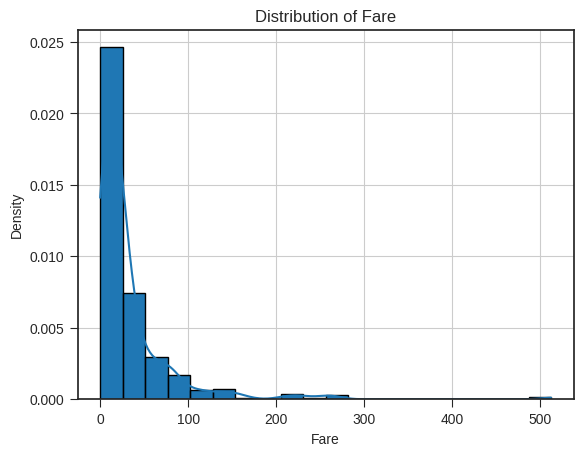

In [252]:
import seaborn as sns
for col in numerical_df.columns:
    numerical_df[col].dropna().hist(bins=20, density=True)
    sns.histplot(numerical_df[col], bins=20, kde=True, stat="density")
    print(f'Mean: {numerical_df[col].mean()} \nMedian: {numerical_df[col].median()}')
    plt.title(f'Distribution of {col}')
    plt.show()

In [276]:
def group_by_col_and_plot(df, col):
    gr = df.groupby(col).size().to_frame(name='Count')
    gr['Ratio'] = np.round(gr['Count'] / gr['Count'].sum() * 100, 0)
    
    print(f'Total number of {col}: {gr["Count"].sum()}')
    
    colors = sns.color_palette(n_colors=len(gr))
    
    # Create subplots
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Bar chart
    gr['Count'].plot(kind='bar', ax=ax1, color=colors, title=f'{col} Counts')
    ax1.set_xlabel('')
    
    # Pie chart
    gr['Ratio'].plot(kind='pie', ax=ax2, color=colors, title=f'{col} Ratio')
    

    plt.tight_layout()
    plt.show()

Total number of Survived: 891


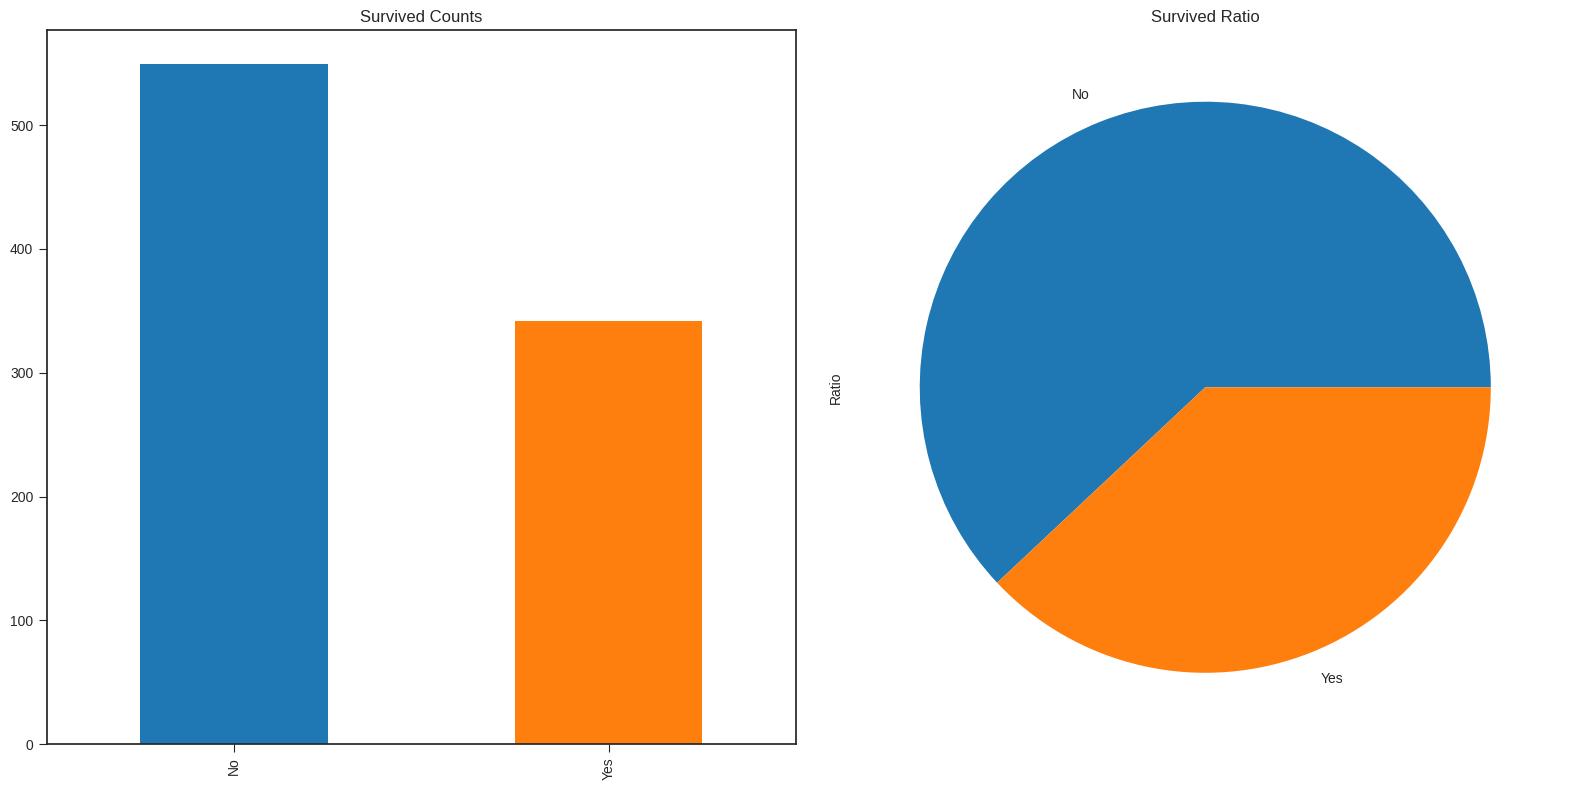

Total number of Pclass: 891


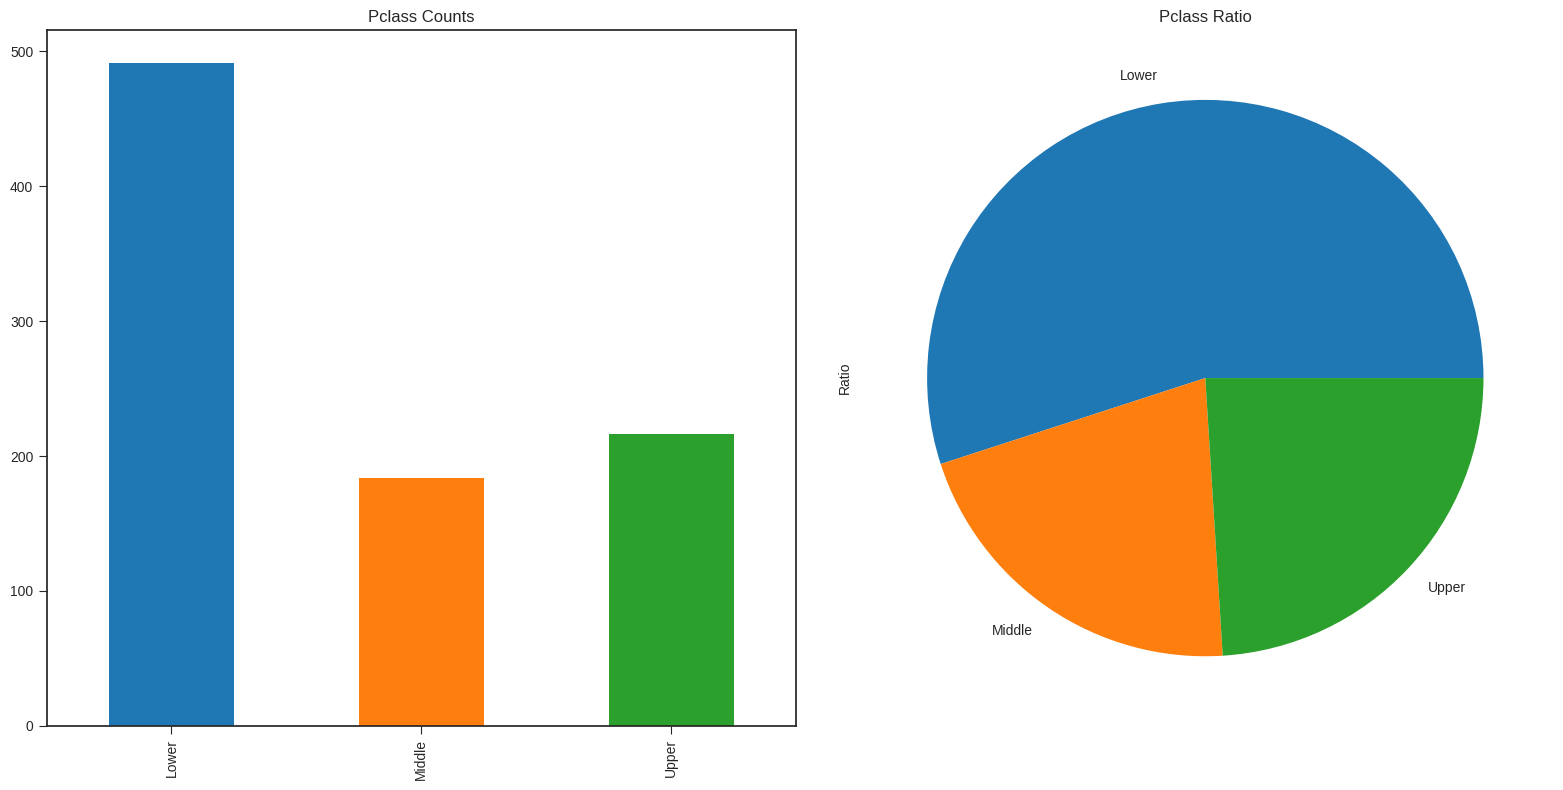

Total number of Sex: 891


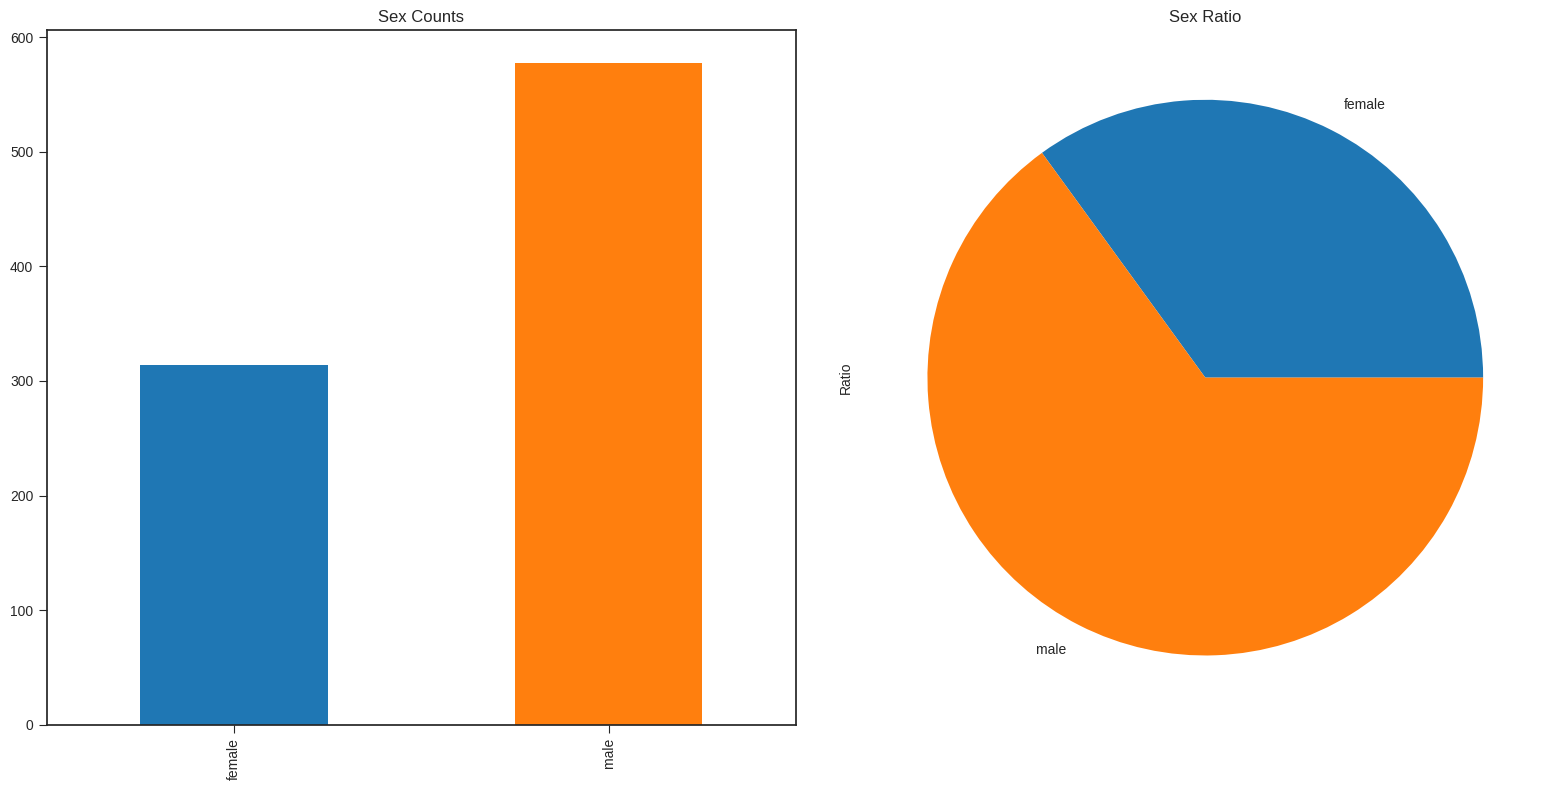

Total number of SibSp: 891


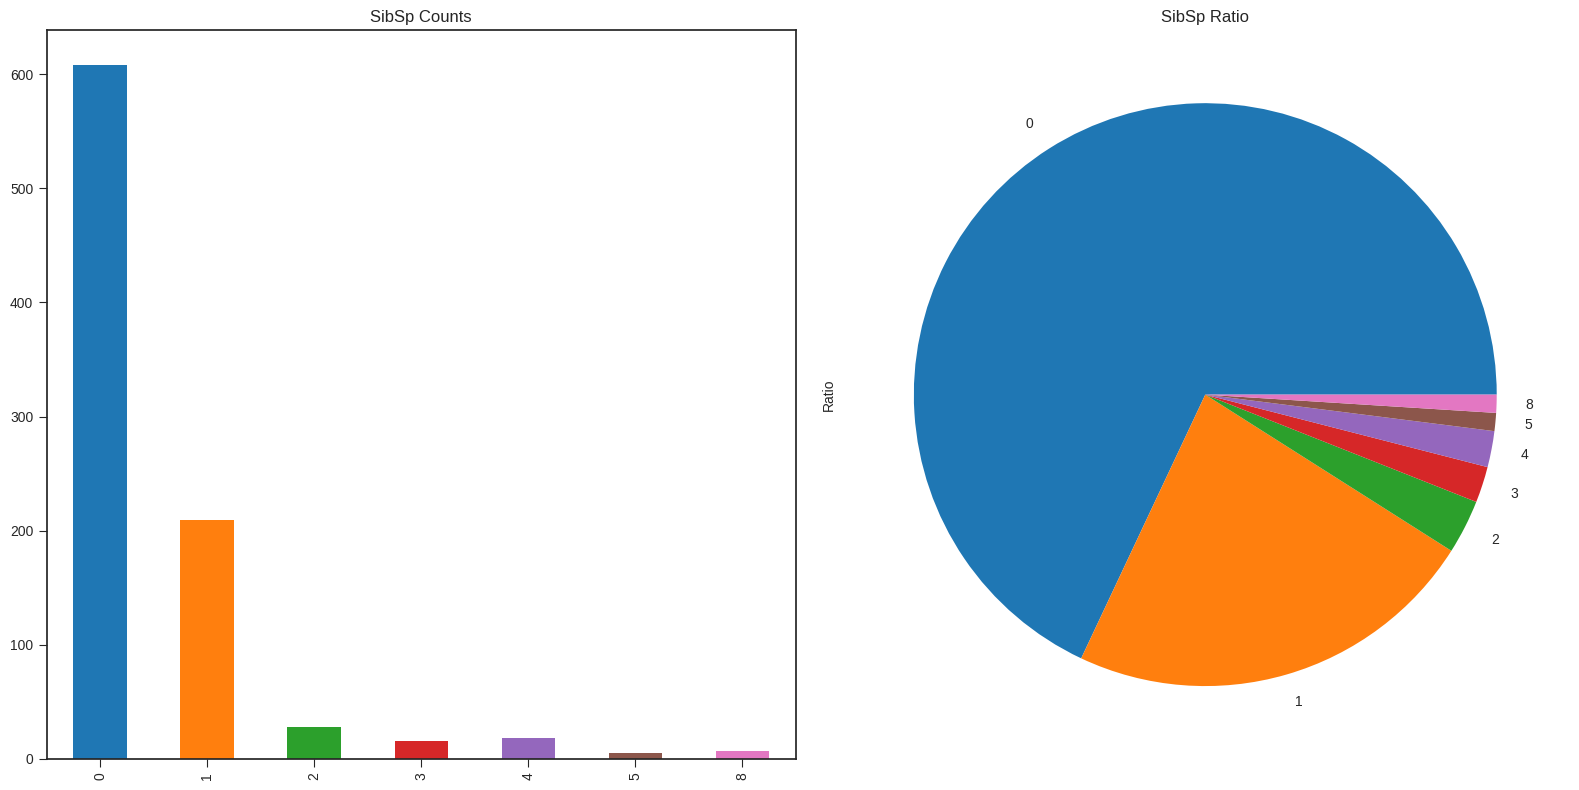

Total number of Parch: 891


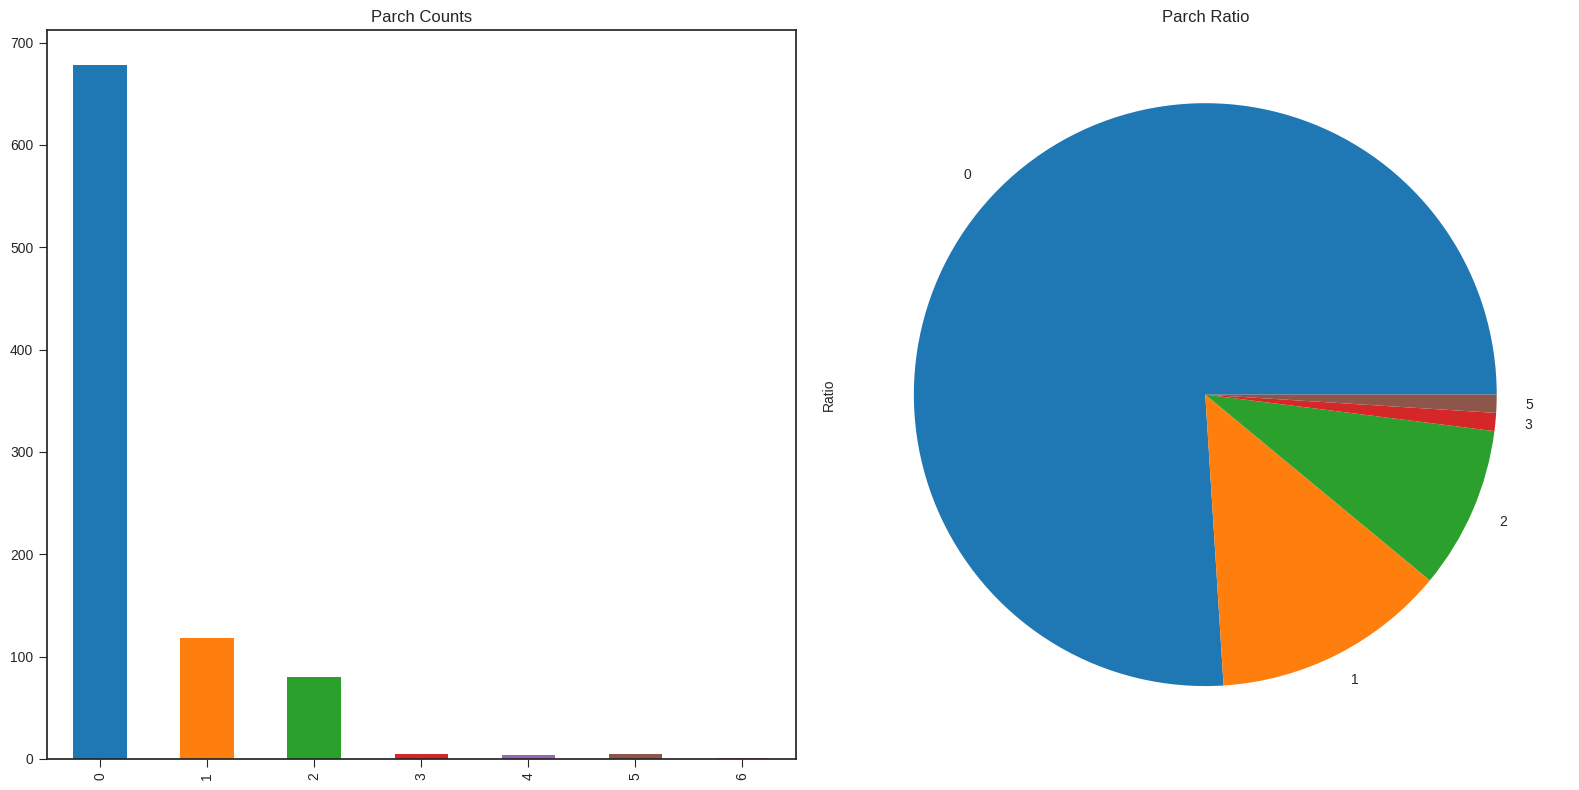

Total number of Embarked: 889


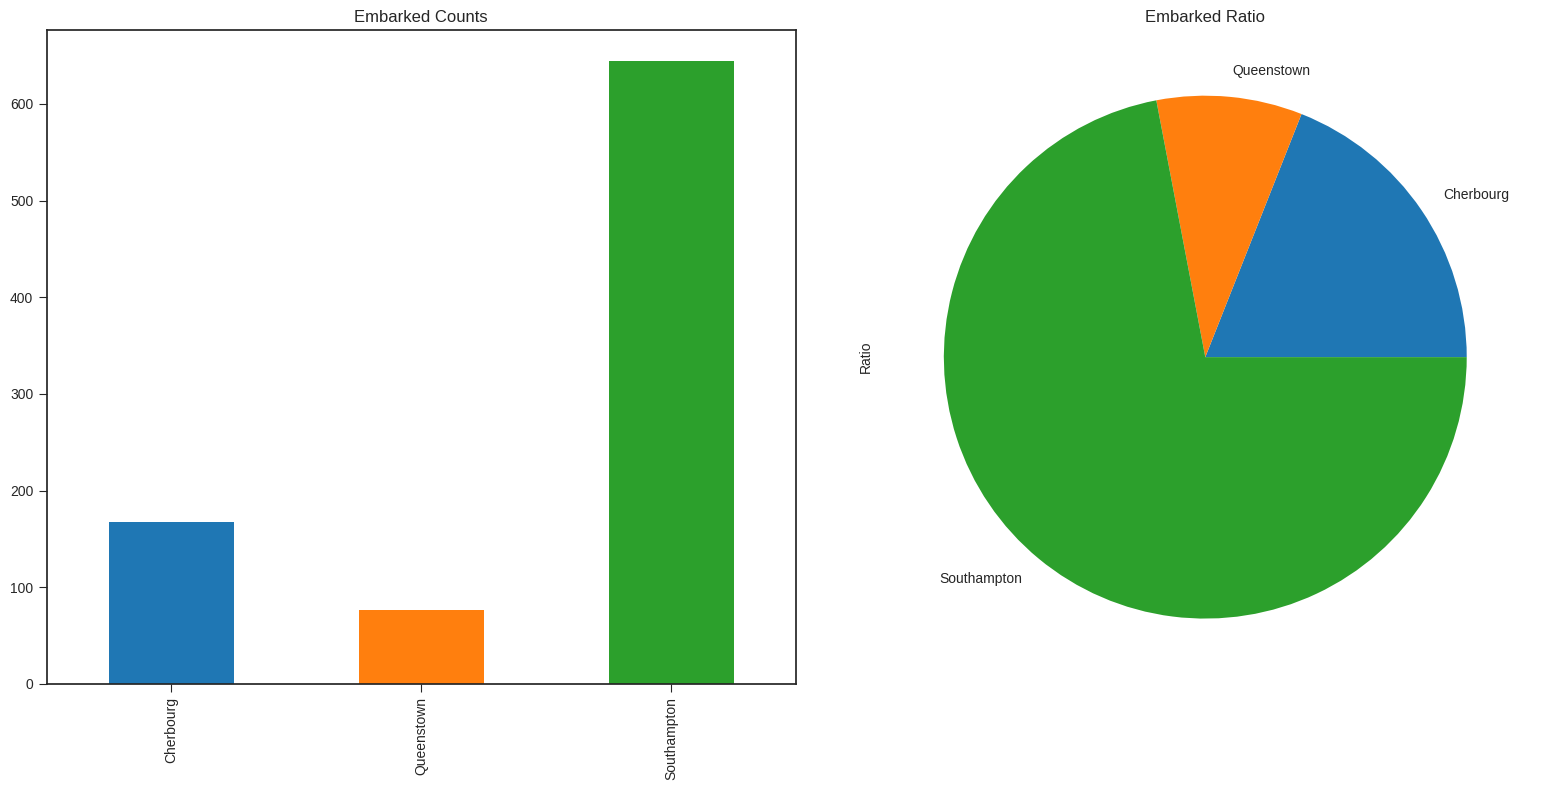

In [277]:
for col in categorical_df.columns:
    group_by_col_and_plot(categorical_df, col)

### Analysis

## Bivariate/Multivariate Analysis

In [255]:
corr_matrix = numeric_df.corr()

# View correlation of all features with 'Survived'
print(corr_matrix['Survived'].sort_values(ascending=False))

KeyError: 'Survived'

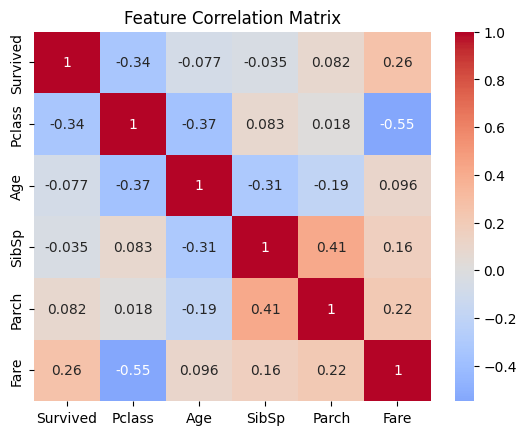

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

## Handle Missing Values & Outliers

## Feature Engineering

In [ ]:
# Encoding the fields to numerical values

def reformat_name(name):
    if ',' in name or '.' in name:
        title = name.split(', ')[1].split('. ')[0].strip()
        return f"{title}"
    return name
    
def reformat_sex(sex):
    return 1 if sex =='male' else 0

def reformat_embark(embark):
    if embark == 'S':
        return 0
    elif embark == 'C':
        return 1
    elif embark == 'Q':
        return 2
    
df['Name'] = df['Name'].apply(reformat_name)
df['Sex'] = df['Sex'].apply(reformat_sex)
df['Embarked'] = df['Embarked'].apply(reformat_embark)

In [ ]:
for col in df.columns:
    num_unique_values = df[col].nunique()
    if num_unique_values / len(df) > 0.5:
        print(f"Column '{col}' has high cardinality with {num_unique_values} unique values over {len(df)} data.")

Column 'Ticket' has high cardinality with 681 unique values over 891 data.


In [ ]:
IGNORED_COLUMNS = ['PassengerId', 'Ticket', 'Cabin']

df.drop(columns=IGNORED_COLUMNS, inplace=True, axis=1)
print(f"\nTruncated dataset shape: {df.shape}")
display(df.head(n=10))

KeyError: "['PassengerId', 'Cabin'] not found in axis"

In [ ]:
# Filled dataset
for col in df.select_dtypes(include=[np.number]).columns:
    skewness = df[col].skew()
    print(f"{col} → skewness: {skewness:.2f}")
    
    if abs(skewness) < 0.5:
        fill_value = df[col].mean()
        method = "mean"
    else:
        fill_value = df[col].median()
        method = "median"
    if df[col].isnull().sum() > 0:
        df.fillna({col: fill_value}, inplace=True)
        print(f"Filled {col} using {method} ({fill_value:.2f})")

Survived → skewness: 0.48
Pclass → skewness: -0.63
Sex → skewness: -0.62
Age → skewness: 0.39
Filled Age using mean (29.70)
SibSp → skewness: 3.70
Parch → skewness: 2.75
Fare → skewness: 4.79
Embarked → skewness: 1.54
Filled Embarked using median (0.00)


In [ ]:
df_encoded = pd.get_dummies(df, columns=['Pclass', 'Name', 'Sex', 'Embarked'], dtype=int, drop_first=True)
df_encoded

,Survived,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Name_Col,Name_Don,Name_Dr,...,Name_Mme,Name_Mr,Name_Mrs,Name_Ms,Name_Rev,Name_Sir,Name_the Countess,Sex_1,Embarked_1.0,Embarked_2.0
0,0,22.000000,1,0,7.2500,0,1,0,0,0,...,0,1,0,0,0,0,0,1,0,0
1,1,38.000000,1,0,71.2833,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
2,1,26.000000,0,0,7.9250,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,35.000000,1,0,53.1000,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,35.000000,0,0,8.0500,0,1,0,0,0,...,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,27.000000,0,0,13.0000,1,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
887,1,19.000000,0,0,30.0000,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
888,0,29.699118,1,2,23.4500,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
889,1,26.000000,0,0,30.0000,0,0,0,0,0,...,0,1,0,0,0,0,0,1,1,0


In [ ]:
for col in df.columns:
    if col == 'Survived':
        continue
    for unique_value in df[col].unique():
        if pd.isna(unique_value):
            continue
        count = df.loc[df[col] == unique_value]["Survived"]
        print(f"% of {col} {unique_value} who survived:", sum(count)/len(count))
    print("-----\n")

% of Pclass 3 who survived: 0.24236252545824846
% of Pclass 1 who survived: 0.6296296296296297
% of Pclass 2 who survived: 0.47282608695652173
-----

% of Name Mr who survived: 0.15667311411992263
% of Name Mrs who survived: 0.792
% of Name Miss who survived: 0.6978021978021978
% of Name Master who survived: 0.575
% of Name Don who survived: 0.0
% of Name Rev who survived: 0.0
% of Name Dr who survived: 0.42857142857142855
% of Name Mme who survived: 1.0
% of Name Ms who survived: 1.0
% of Name Major who survived: 0.5
% of Name Lady who survived: 1.0
% of Name Sir who survived: 1.0
% of Name Mlle who survived: 1.0
% of Name Col who survived: 0.5
% of Name Capt who survived: 0.0
% of Name the Countess who survived: 1.0
% of Name Jonkheer who survived: 0.0
-----

% of Sex 1 who survived: 0.18890814558058924
% of Sex 0 who survived: 0.7420382165605095
-----

% of Age 22.0 who survived: 0.4074074074074074
% of Age 38.0 who survived: 0.45454545454545453
% of Age 26.0 who survived: 0.3333333

## Key Insights & Summary

- Insight 1
- Insight 2
- Suggested next steps (e.g., modeling, deeper analysis)